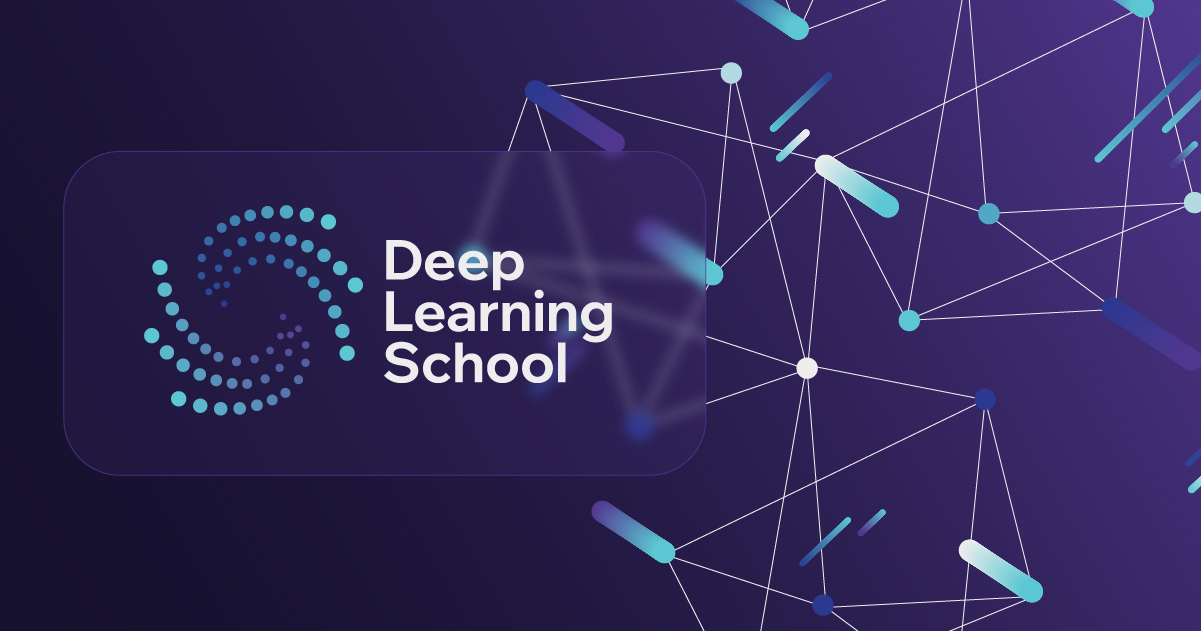

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>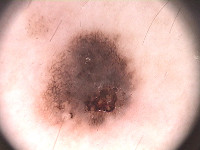</td><td>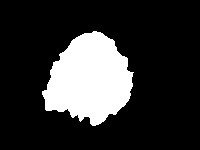</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [2]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=dd52e7ce-e285-4577-91bf-30f455e51665
To: C:\prj\DLS\dsl_part_1_ml_cv\week_08_semantic_segmentation\Homework\PH2Dataset.rar

  0%|          | 0.00/162M [00:00<?, ?B/s]
  0%|          | 524k/162M [00:00<02:21, 1.14MB/s]
  1%|          | 1.05M/162M [00:00<01:49, 1.46MB/s]
  1%|          | 1.57M/162M [00:01<01:51, 1.44MB/s]
  1%|1         | 2.10M/162M [00:02<04:05, 652kB/s] 
  2%|1         | 2.62M/162M [00:02<03:15, 813kB/s]
  2%|1         | 3.15M/162M [00:04<04:06, 644kB/s]
  2%|2         | 3.67M/162M [00:04<03:24, 773kB/s]
  3%|2         | 4.19M/162M [00:05<03:11, 825kB/s]
  3%|2         | 4.72M/162M [00:05<02:42, 968kB/s]
  3%|3         | 5.24M/162M [00:05<02:23, 1.09MB/s]
  4%|3         | 5.77M/162M [00:06<02:08, 1.22MB/s]
  4%|3         | 6.29M/162M [00:06<01:49, 1.43MB/s]
  4%|4         | 6.

In [ ]:
# get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [ ]:
#!pip install scikit-image

In [1]:
images = []
lesions = []
import os

from skimage.io import imread

# root = 'E:\\data\\PH2Dataset'
# root = 'C:\\prj\\DLS\\data\\PH2Dataset'
root = 'D:\\Data\\PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [2]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True, ) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [4]:
import numpy as np

X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')
print(f'Loaded {len(Y)} images')

Loaded 200 images
Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

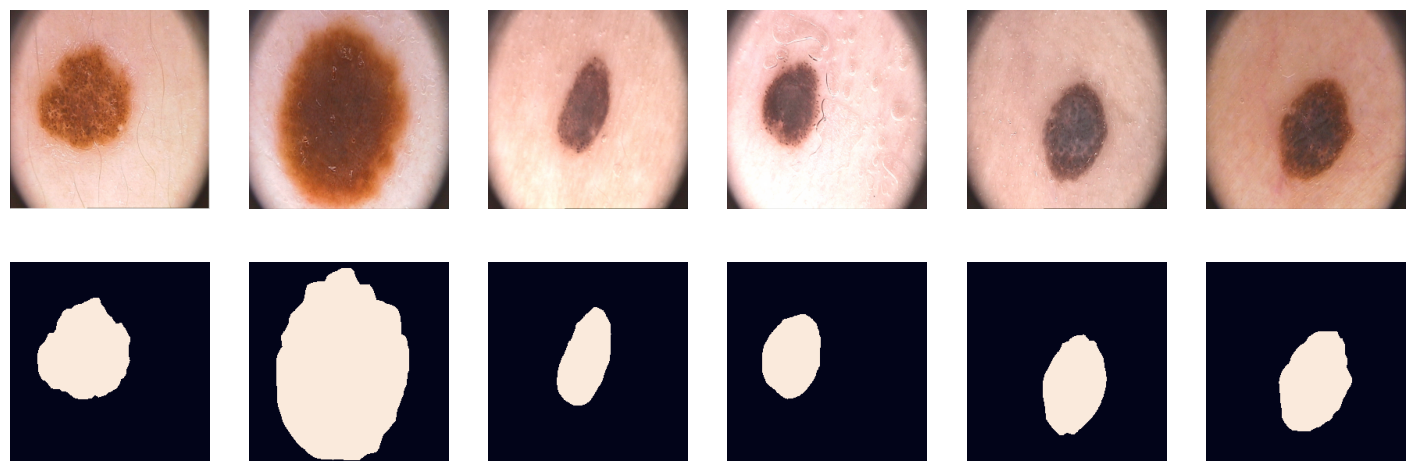

In [30]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.axis("off")
    plt.imshow(X[i + 10])

    plt.subplot(2, 6, i + 7)
    plt.axis("off")
    plt.imshow(Y[i + 10])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [5]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [6]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [7]:
from torch.utils.data import DataLoader

batch_size = 4
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                              batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                              batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                             batch_size=batch_size, shuffle=True)

In [8]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:



<p style="align: center;"><img align=center src="https://drive.usercontent.google.com/download?id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN&export=view&authuser=0" width=1000 height=800/></p>

In [9]:
# !pip install torchmetrics

In [31]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## BCE Loss [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

Исходная формула BCE для одного элемента:
$$
\mathcal{L}_{BCE}(y, \hat{y}) = -y \log(\sigma(\hat{y})) - (1-y)\log(1-\sigma(\hat{y}))
$$

Где $\sigma(\hat{y}) = \frac{1}{1 + e^{-\hat{y}}}$


Подставляем  $\sigma(\hat{y})$ 
$$
\log(\sigma(\hat{y})) = \log\left(\frac{1}{1+e^{-\hat{y}}}\right) = -\log(1 + e^{-\hat{y}})
$$



Подставим в $\log(1-\sigma(\hat{y}))$ значение $\sigma(\hat{y})$
$$
1 - \sigma(\hat{y}) = \frac{e^{-\hat{y}}}{1 + e^{-\hat{y}}}
$$
$$
\log(1-\sigma(\hat{y})) = \log\left(\frac{e^{-\hat{y}}}{1+e^{-\hat{y}}}\right) = -\hat{y} - \log(1 + e^{-\hat{y}})
$$



По исходной формуле
$$
\mathcal{L}_{BCE} = -y[-\log(1 + e^{-\hat{y}})] - (1-y)[-\hat{y} - \log(1 + e^{-\hat{y}})]
$$

$$
= y\log(1 + e^{-\hat{y}}) + (1-y)\hat{y} + (1-y)\log(1 + e^{-\hat{y}})
$$


Вынесем за скобки $\log(1 + e^{-\hat{y}})$

$$
= [y + (1-y)]\log(1 + e^{-\hat{y}}) + (1-y)\hat{y}
$$
$$
= \log(1 + e^{-\hat{y}}) + \hat{y} - y\hat{y}
$$



---




$$
\mathcal{L}_{BCE} = \hat{y} - y\hat{y} + \log(1 + e^{-\hat{y}})
$$



### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [51]:
import torch.nn as nn

In [52]:
bce_torch = nn.BCELoss(reduction='sum')  # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [53]:
def bce_true(y_hat, y):
    probs = torch.sigmoid(y_hat)
    all_y = y * torch.log(probs + 1e-8) + (1 - y) * torch.log(1 - probs + 1e-8)
    loss = -torch.sum(all_y)
    return loss

In [54]:
def bce_loss(y_hat, y):
    all_y = y_hat - y * y_hat + torch.log1p(torch.exp(-y_hat))
    loss = torch.sum(all_y)
    return loss

Проверим корректность работы на простом примере

In [55]:
def iou_pytorch(outputs, labels):
    outputs = outputs.squeeze().byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels =(labels).squeeze().byte()
    SMOOTH = 1e-8
    intersection = (outputs & labels).float().sum((1, 2))  # Will be zero if Truth=0 or Prediction=0
    union = (outputs | labels).float().sum((1, 2))         # Will be zero if both are 0

    iou = (intersection + SMOOTH) / (union + SMOOTH)  # We smooth our devision to avoid 0/0
    return iou

In [72]:
def bce_Logits(y_pred, y_true):
    bcelogits_loss = -y_true * torch.log(torch.sigmoid(y_pred)) - (1 - y_true) * torch.log(torch.sigmoid(1 - y_pred))
    # работает хорошо без упрощения

    return bcelogits_loss

In [73]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

In [74]:
bce_Logits(y_pred, y_true).mean()

tensor(0.6079)

In [77]:

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 4.93065071105957
BCE loss честно посчитанный = 4.93065071105957
BCE loss from torch bce_torch = 4.93065071105957
BCE loss from torch with logits bce_torch = 4.93065071105957


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [18]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [19]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 13.632895469665527
BCE loss честно посчитанный = 13.632895469665527
BCE loss from torch bce_torch = 13.632895469665527
BCE loss from torch with logits bce_torch = 13.632895469665527


In [20]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [21]:
# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt


Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: C:\prj\DLS\dsl_part_1_ml_cv\week_08_semantic_segmentation\Homework\for_asserts\labels.pt

  0%|          | 0.00/1.18k [00:00<?, ?B/s]
100%|##########| 1.18k/1.18k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: C:\prj\DLS\dsl_part_1_ml_cv\week_08_semantic_segmentation\Homework\for_asserts\logits.pt

  0%|          | 0.00/1.18k [00:00<?, ?B/s]
100%|##########| 1.18k/1.18k [00:00<00:00, 1.18MB/s]
Download completed


In [23]:
# path_to_dummy_samples = '..\\..\\for_asserts'
path_to_dummy_samples = 'for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

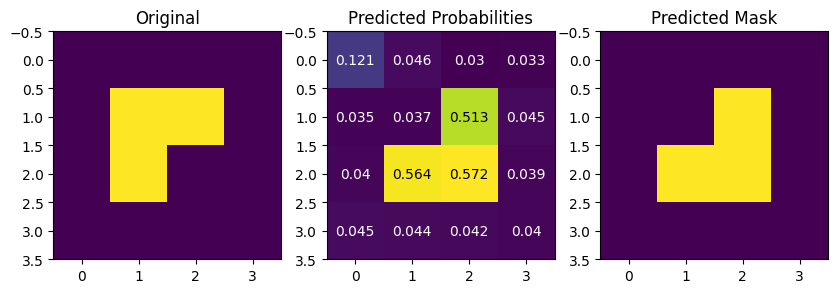

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3 * 10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j, i), label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i, j, round(label, 3), color=color, ha='center', va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [25]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(),
                                                    dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

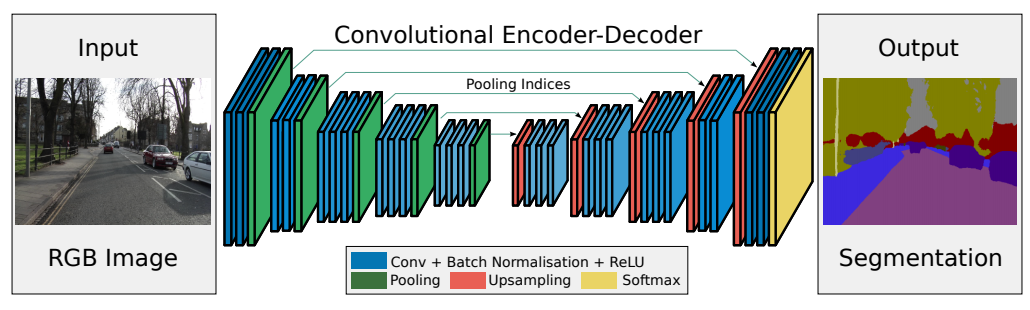

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

In [16]:
import torch
import torch.nn as nn
from time import time

from matplotlib import rcParams

rcParams['figure.figsize'] = (15, 4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


рассмотрим сверточную сеть VGG16  для создания кодера нашей реализации SegNet

In [27]:
from torchvision import models

template = models.vgg16_bn()
# template

Архитектуру Segnet необходимо реализовать для нашей задачи: 256х256 и 2 класа

In [11]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling) consists of convolutional layers and pooling layers with ReLU activation and batchnorm

        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                  dilation=1,
                                  ceil_mode=False, return_indices=True)
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                  dilation=1,
                                  ceil_mode=False, return_indices=True)
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                  dilation=1,
                                  ceil_mode=False, return_indices=True)
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)

        # bottleneck layer improves the training metrics
        self.bottleneck_enc = nn.Sequential(
            nn.Conv2d(512, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )

        # decoder (upsampling) consist of unpooling layers that are feeded with indexes from encoder and of conv layers
        # (with ReLU and batchnorm as well)
        self.upsample0 = nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0)  # 16->32
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.upsample1 = nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0)  # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample2 = nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0)  # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.upsample3 = nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0)  # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
        )

    def forward(self, x):
        # encoder
        e0, idx0 = self.pool0(self.enc_conv0(x))
        e1, idx1 = self.pool1(self.enc_conv1(e0))
        e2, idx2 = self.pool2(self.enc_conv2(e1))
        e3, idx3 = self.pool3(self.enc_conv3(e2))

        # bottleneck
        b = self.bottleneck_enc(e3)
        # decoder: here we feed the indexes from encoder to the unpooling layers
        d0 = self.dec_conv0(self.upsample0(b, idx3))
        d1 = self.dec_conv1(self.upsample1(d0, idx2))
        d2 = self.dec_conv2(self.upsample2(d1, idx1))
        d3 = self.dec_conv3(self.upsample3(d2, idx0))  # no activation
        return d3

In [29]:
segnet_model = SegNet().to(device)

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [35]:
from IPython.display import clear_output

In [79]:
def train(model, opt, loss_fn, epochs, data_tr, data_val, sched=None, freq=1):
    history = []
    for epoch in range(epochs):
        tic = time()
        print(f'Epoch {epoch + 1} of {epochs}')
        avg_val_loss = 0
        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in data_tr:
            # data to device
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            # set gradients to zero
            opt.zero_grad()
            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_pred, Y_batch)
            loss.mean().backward()
            # loss.backward()
            opt.step()

            # calculate train loss
            avg_loss += loss.mean() / len(data_tr)
        toc = time()
        print(f'loss: {avg_loss}')

        # calculate val loss and metrics
        model.eval()  # testing mode
        with torch.no_grad():
            for X_val, Y_val in data_val:
                # data to device
                X_val, Y_val = X_val.to(device), Y_val.to(device)
                Y_val_pred = model(X_val)
                loss_val = loss_fn(Y_val_pred, Y_val)
                avg_val_loss += loss_val.mean() / len(data_val)
                # avg_val_loss += loss_val / len(data_val)
            Y_hat = (torch.sigmoid(model(X_val).squeeze()) > 0.5).to(int)
            val_metric = iou_pytorch(Y_hat, Y_val)
            # val_metric = iou_score(Y_hat, Y_val)
            Y_train_hat = (torch.sigmoid(model(X_batch).squeeze()) > 0.5).to(int)
            train_metric = iou_pytorch(Y_train_hat, Y_batch)
            # train_metric = iou_score(Y_train_hat, Y_batch)
        # make a scheduler step
        if sched:
            if epoch % freq == 0:
                sched.step()

        # save the training history
        history.append((avg_loss.item(), avg_val_loss.item(), train_metric.mean().item(), val_metric.mean().item()))

        # Visualize tools
        clear_output(wait=True)
        Y_hat = Y_hat.detach().cpu().numpy()
        plt.figure(figsize=(4, 4))
        for k in range(2):
            plt.subplot(2, 2, k + 1)
            plt.imshow(np.rollaxis(X_val[k].cpu().numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 2, k + 3)
            plt.imshow(Y_hat[k, :, :], cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch + 1, epochs, avg_loss))
        plt.show()
    return history

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [80]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.memory_allocated()

0

In [81]:
model = SegNet().to(device)
max_epochs = 50
opt = torch.optim.AdamW(model.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_bce = train(model, opt, bce_Logits, max_epochs, train_dataloader, valid_dataloader)


In [82]:
torch.save(model, 'SegNet_model.pth')

In [83]:
history_bce

[(0.34931209683418274,
  0.44203847646713257,
  1.4912019651092123e-05,
  3.319906318210997e-05),
 (0.27235594391822815,
  0.33429965376853943,
  0.5804288983345032,
  0.5387976169586182),
 (0.23450987040996552,
  0.20702683925628662,
  0.8509565591812134,
  0.7873483300209045),
 (0.18786589801311493,
  0.19703322649002075,
  0.801267147064209,
  0.7228312492370605),
 (0.17506244778633118,
  0.1780950278043747,
  0.8491897583007812,
  0.7389259338378906),
 (0.16484524309635162,
  0.1586425006389618,
  0.7938100099563599,
  0.8196552991867065),
 (0.16874369978904724,
  0.19974789023399353,
  0.8329715728759766,
  0.6678761839866638),
 (0.161624476313591,
  0.1846710592508316,
  0.7753177881240845,
  0.6867389678955078),
 (0.14819079637527466,
  0.15767404437065125,
  0.9070630073547363,
  0.8508268594741821),
 (0.12882524728775024,
  0.1490175426006317,
  0.8238662481307983,
  0.8488718271255493),
 (0.11915752291679382,
  0.1812388151884079,
  0.7792432308197021,
  0.9034474492073059),


In [85]:
import pickle
with open('history_bce', 'wb') as f:
    pickle.dump(history_bce, f)

In [ ]:
with open('history_bce', 'rb') as f:
    history_bce = pickle.load(f)

## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [17]:
def predict(model, data):
    test_dataset = np.rollaxis(data, 3, 1)
    model.eval()  # testing mode
    Y_pred = np.zeros(len(data), dtype='object')
    idx = 0
    with torch.no_grad():
        X = torch.FloatTensor(test_dataset).to(device)
        preds = (torch.sigmoid(model(X)).squeeze() > 0.5).to(int).cpu().numpy()
        for X in preds:
            Y_pred[idx] = X
            idx += 1
    return Y_pred


In [18]:
def score_model(model, metric, data):
    model.eval()  # testing mode
    scores = 0
    with torch.no_grad():
        for X_batch, Y_label in data:
            Y_pred = (torch.sigmoid(model(X_batch.to(device)).squeeze()) > 0.5).to(int)
            scores += metric(Y_pred, Y_label.to(device)).mean().item()
    return scores / len(data)

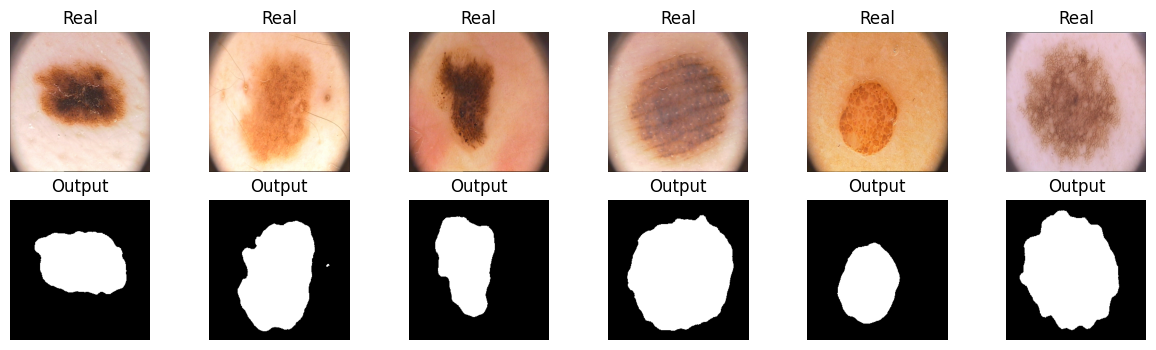

In [21]:
# Проверим, как работает функция прогнозирования:
Y_pred = predict(model, X[ts])

for k in range(6):
    plt.subplot(2, 6, k + 1)
    plt.imshow(X[ts][k])
    plt.title('Real')
    plt.axis('off')

    plt.subplot(2, 6, k + 7)
    plt.imshow(Y_pred[k], cmap='gray')
    plt.title('Output')
    plt.axis('off')

# it works okay and the model is strong enough to train on our small dataset!

In [ ]:
def test(...):

# TODO

In [ ]:
test(...)

# Мир других лоссов!

## Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [88]:
def dice_score(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    preds = preds.view(-1)
    targets = targets.view(-1).float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2. * intersection) / union

    return dice

Проверим на корректность функцию dice_score:

In [89]:
d1 = dice_score(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'])
d1.item()

0.4244002103805542

In [90]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(average='micro', num_classes=1).to(device)
d2 = dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'])
d2.item()

0.4244002103805542

In [91]:
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels']) == dice_score(dummpy_sample['logits'].sigmoid(),
                                                                               dummpy_sample['labels'])

tensor(True)

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
# !pip install monai

In [83]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    preds = torch.sigmoid(logits)

    preds = preds.view(-1)
    labels = labels.view(-1).float()

    intersection = (preds * labels).sum()
    union = preds.sum() + labels.sum()

    dice = (2. * intersection + smooth) / (union + smooth)
    loss = 1. - dice

    return loss

Проверка на корректность:

In [108]:
from monai.losses import DiceLoss

dice_loss_torch = DiceLoss(sigmoid=True, smooth_nr=0, smooth_dr=0)

In [109]:
dice_loss(dummpy_sample['logits'], dummpy_sample['labels'], smooth=0).item()

0.5755997896194458

In [110]:
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']).item()

0.5755997896194458

In [111]:
assert (dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) ==
        dice_loss(dummpy_sample['logits'], dummpy_sample['labels'], smooth=0))

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [116]:
def focal_loss(logits, targets, alpha=-1, gamma=2, reduction='sum'):
    p = torch.sigmoid(logits)

    # Вычисляем кросс-энтропийный член
    ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

    # Вычисляем p_t
    p_t = p * targets + (1 - p) * (1 - targets)

    # Вычисляем фактор фокусировки
    modulating_factor = (1.0 - p_t) ** gamma

    # Вычисляем альфа-балансирующий фактор
    if alpha >= 0:
        alpha_factor = alpha * targets + (1 - alpha) * (1 - targets)
    else:
        alpha_factor = 1.0

    # Собираем все вместе
    focal_loss = alpha_factor * modulating_factor * ce_loss

    # Применяем сокращение
    if reduction == 'none':
        return focal_loss
    elif reduction == 'mean':
        return focal_loss.mean()
    elif reduction == 'sum':
        return focal_loss.sum()
    else:
        raise ValueError(f"Unsupported reduction mode: {reduction}. Use 'none', 'mean' or 'sum'")

Проверка корректности функции:

In [117]:
from torchvision.ops import sigmoid_focal_loss

sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161)

In [118]:
focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161)

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2,
                          reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



# Новая модель!

## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

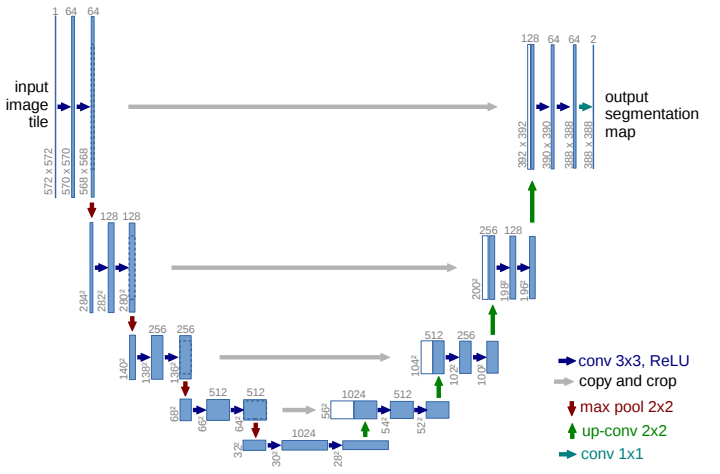

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

In [ ]:

import torch.nn as nn

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        # TODO

    def forward(self, x):
        #  TODO

        return output

In [ ]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.

